In [ ]:
#Dane dotyczące bezrobocia pobrane z eurostatu:
#Do wyboru była wersja SA (seasonally adjusted) oraz NSA (not seasonally adjusted), w naszym projekcie wybraliśmy
#SA żeby uniknąć szumu spowodowanego pracami sezonowymi

In [1435]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("unemployment_monthly_total_sa.csv")

In [1436]:
df.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,unit,Unit of measure,s_adj,Seasonal adjustment,indic,...,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:EI_LMHR_M(1.0),Unemployment rate (%) - monthly data,M,Monthly,PC_ACT,Percentage of population in the labour force,SA,"Seasonally adjusted data, not calendar adjuste...",LM-UN-T-TOT,...,AT,Austria,1995-01,NaN,4.0,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:EI_LMHR_M(1.0),Unemployment rate (%) - monthly data,M,Monthly,PC_ACT,Percentage of population in the labour force,SA,"Seasonally adjusted data, not calendar adjuste...",LM-UN-T-TOT,...,AT,Austria,1995-02,NaN,3.9,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:EI_LMHR_M(1.0),Unemployment rate (%) - monthly data,M,Monthly,PC_ACT,Percentage of population in the labour force,SA,"Seasonally adjusted data, not calendar adjuste...",LM-UN-T-TOT,...,AT,Austria,1995-03,NaN,3.9,NaN,NaN,NaN,NaN,NaN
3,dataflow,ESTAT:EI_LMHR_M(1.0),Unemployment rate (%) - monthly data,M,Monthly,PC_ACT,Percentage of population in the labour force,SA,"Seasonally adjusted data, not calendar adjuste...",LM-UN-T-TOT,...,AT,Austria,1995-04,NaN,4.0,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:EI_LMHR_M(1.0),Unemployment rate (%) - monthly data,M,Monthly,PC_ACT,Percentage of population in the labour force,SA,"Seasonally adjusted data, not calendar adjuste...",LM-UN-T-TOT,...,AT,Austria,1995-05,NaN,4.1,NaN,NaN,NaN,NaN,NaN


In [1437]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14756 entries, 0 to 14755
Data columns (total 21 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   STRUCTURE                               14756 non-null  object 
 1   STRUCTURE_ID                            14756 non-null  object 
 2   STRUCTURE_NAME                          14756 non-null  object 
 3   freq                                    14756 non-null  object 
 4   Time frequency                          14756 non-null  object 
 5   unit                                    14756 non-null  object 
 6   Unit of measure                         14756 non-null  object 
 7   s_adj                                   14756 non-null  object 
 8   Seasonal adjustment                     14756 non-null  object 
 9   indic                                   14756 non-null  object 
 10  Indicator                               14756 non-null  ob

In [1438]:
#W pobranych danych znajduje się dużo oznaczeń dotyczących struktury i metadata eurostatu, które będą niepotrzebne przy dalszej pracy na danych 
#Finalnie z tego datasetu będą potrzebne 3 kolumny:
# - geo - kraj/zbiór krajów
# - TIME_PERIOD - miesiąc
# - unemployment - współczynnik bezrobocia
#Seasonal adjustment jak bylo wspominanie wyżej zostalo już zdefiniowane przy pobieraniu
#Zostawiamy jeszcze kolumne Geopolitical entity (reporting) która zawiera pełną nazwe kraju w celu wygody przy rysowaniu wykresow

In [1439]:
df = df[["geo", "Geopolitical entity (reporting)", "TIME_PERIOD", "OBS_VALUE"]]

df = df.rename(columns={
    "TIME_PERIOD": "time",
    "OBS_VALUE": "unemployment",
    "Geopolitical entity (reporting)": "country"
})

df["time"] = pd.to_datetime(df["time"])

df = df.sort_values(["geo", "time"]).reset_index(drop=True)

df["geo"] = df["geo"].astype("category")

print(df.head())

  geo  country       time  unemployment
0  AT  Austria 1995-01-01           4.0
1  AT  Austria 1995-02-01           3.9
2  AT  Austria 1995-03-01           3.9
3  AT  Austria 1995-04-01           4.0
4  AT  Austria 1995-05-01           4.1


In [1440]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14756 entries, 0 to 14755
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   geo           14756 non-null  category      
 1   country       14756 non-null  object        
 2   time          14756 non-null  datetime64[ns]
 3   unemployment  14756 non-null  float64       
dtypes: category(1), datetime64[ns](1), float64(1), object(1)
memory usage: 361.7+ KB


In [1441]:
#Sprawdzenie danych pod kątem nulli
df.isna().sum()

geo             0
country         0
time            0
unemployment    0
dtype: int64

In [1442]:
#Zakres dat
print(df["time"].min())
print(df["time"].max())

1983-01-01 00:00:00
2026-04-01 00:00:00


In [1443]:
#Kraje
countries = sorted(df["country"].unique())
print(countries)

['Austria', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Estonia', 'Euro area – 21 countries (from 2026)', 'European Union - 27 countries (from 2020)', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Italy', 'Japan', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Türkiye', 'United Kingdom', 'United States']


In [1444]:
#Do usunięcia są jeszcze agregatory typu Euro area, zostawiamy jedynie European Union - 27 countries (from 2020) oraz kraje spoza UE
#Następnie rozdzielamy kraje oraz UE na dwa osobne bloki i UE będzie od teraz traktowany jako wskaźnik ogólnej sytuacji gospodarczej (dodatkowa kolumna)
eu_codes_all = [
    'AT','BE','BG','HR','CY','CZ','DK','EE','FI','FR',
    'DE','EL','HU','IE','IT','LV','LT','LU','MT','NL',
    'PL','PT','RO','SK','SI','ES','SE',
    'EU27_2020'
]

df_all = df[df["geo"].isin(eu_codes_all)]

#Tylko kraje
df_countries = df_all[df_all["geo"] != "EU27_2020"]

#Tylko UE
df_eu = df_all[df_all["geo"] == "EU27_2020"]


df_final = df_countries.merge(
    df_eu[["time", "unemployment"]],
    on="time",
    how="left"
)

df_final = df_final.rename(columns={
    "unemployment_x": "unemployment",
    "unemployment_y": "unemployment_eu"
})

In [1445]:
df_final.head()

,geo,country,time,unemployment,unemployment_eu
0,AT,Austria,1995-01-01,4.0,NaN
1,AT,Austria,1995-02-01,3.9,NaN
2,AT,Austria,1995-03-01,3.9,NaN
3,AT,Austria,1995-04-01,4.0,NaN
4,AT,Austria,1995-05-01,4.1,NaN


In [1446]:
df_final.isna().sum()

geo                   0
country               0
time                  0
unemployment          0
unemployment_eu    2616
dtype: int64

In [1447]:
#Pojawia sie jednak problem z zakresem (UE ma dane dopiero od 2000 roku, więc trzeba będzie obciąć dane tak zeby zaczynaly sie od 2000 roku)
print(df_countries["time"].min(), df_countries["time"].max())
print(df_eu["time"].min(), df_eu["time"].max())

1983-01-01 00:00:00 2026-04-01 00:00:00
2000-01-01 00:00:00 2026-04-01 00:00:00


In [1448]:
start = df_eu["time"].min()
df_countries_trimmed = df_countries[df_countries["time"] >= start]

df_final = df_countries_trimmed.merge(
    df_eu[["time", "unemployment"]],
    on="time",
    how="left"
)

df_final = df_final.rename(columns={
    "unemployment_x": "unemployment",
    "unemployment_y": "unemployment_eu"
})

In [1449]:
df_final.isna().sum()

geo                0
country            0
time               0
unemployment       0
unemployment_eu    0
dtype: int64

In [1450]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8531 entries, 0 to 8530
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   geo              8531 non-null   category      
 1   country          8531 non-null   object        
 2   time             8531 non-null   datetime64[ns]
 3   unemployment     8531 non-null   float64       
 4   unemployment_eu  8531 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(2), object(1)
memory usage: 276.4+ KB


In [1451]:
df_final.head()

,geo,country,time,unemployment,unemployment_eu
0,AT,Austria,2000-01-01,4.3,9.7
1,AT,Austria,2000-02-01,4.3,9.7
2,AT,Austria,2000-03-01,4.1,9.7
3,AT,Austria,2000-04-01,3.8,9.6
4,AT,Austria,2000-05-01,3.7,9.6


In [1452]:
df_final.tail()

,geo,country,time,unemployment,unemployment_eu
8526,SK,Slovakia,2025-12-01,5.7,6.0
8527,SK,Slovakia,2026-01-01,5.7,6.0
8528,SK,Slovakia,2026-02-01,5.8,6.0
8529,SK,Slovakia,2026-03-01,5.8,6.0
8530,SK,Slovakia,2026-04-01,5.8,6.0


In [1453]:
#Kolejną cechę którą uwzględnimy w naszych danych będzie inflacja, dane eurostatu umożliwiają pobrać ją w wersji miesięcznej inflacja rok do roku (%)
#Dodatkowo wybraliśmy całkowitą inflacje (tzn nie rozbijaną na np. jedzenie, energię etc.)
df2 = pd.read_csv("inflation_monthly_total_year_to_year.csv")
df2.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,unit,Unit of measure,coicop18,Classification of individual consumption by purpose (COICOP) - 2018,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:PRC_HICP_MINR(1.0),Harmonised index of consumer prices (HICP) - E...,M,Monthly,RCH_A,Annual rate of change,TOTAL,Total,AL,Albania,2016-12,NaN,2.5,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:PRC_HICP_MINR(1.0),Harmonised index of consumer prices (HICP) - E...,M,Monthly,RCH_A,Annual rate of change,TOTAL,Total,AL,Albania,2017-01,NaN,4.0,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:PRC_HICP_MINR(1.0),Harmonised index of consumer prices (HICP) - E...,M,Monthly,RCH_A,Annual rate of change,TOTAL,Total,AL,Albania,2017-02,NaN,3.7,NaN,NaN,NaN,NaN,NaN
3,dataflow,ESTAT:PRC_HICP_MINR(1.0),Harmonised index of consumer prices (HICP) - E...,M,Monthly,RCH_A,Annual rate of change,TOTAL,Total,AL,Albania,2017-03,NaN,3.8,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:PRC_HICP_MINR(1.0),Harmonised index of consumer prices (HICP) - E...,M,Monthly,RCH_A,Annual rate of change,TOTAL,Total,AL,Albania,2017-04,NaN,3.6,NaN,NaN,NaN,NaN,NaN


In [1454]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13964 entries, 0 to 13963
Data columns (total 19 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   STRUCTURE                                                            13964 non-null  object 
 1   STRUCTURE_ID                                                         13964 non-null  object 
 2   STRUCTURE_NAME                                                       13964 non-null  object 
 3   freq                                                                 13964 non-null  object 
 4   Time frequency                                                       13964 non-null  object 
 5   unit                                                                 13964 non-null  object 
 6   Unit of measure                                                      13964 non-null  object 
 7   coic

In [1455]:
#Z inflacji będziemy potrzebować kolumny OBS_VALUE czyli wartości inflacji oraz TIME_PERIOD


df_inf = df2[[
    "geo", 
    "Geopolitical entity (reporting)", 
    "TIME_PERIOD", 
    "OBS_VALUE"
]]

df_inf = df_inf.rename(columns={
    "Geopolitical entity (reporting)": "country",
    "TIME_PERIOD": "time",
    "OBS_VALUE": "inflation"
})

df_inf["time"] = pd.to_datetime(df_inf["time"])

df_inf = df_inf.sort_values(["geo", "time"]).reset_index(drop=True)

df_inf["geo"] = df_inf["geo"].astype("category")

#Uwzglednienie tylko krajów UE bez samej UE jako zbiorczej wartości
df_inf = df_inf[df_inf["geo"].isin(
    [code for code in eu_codes_all if code != "EU27_2020"]
)]

print(df_inf.head())

    geo  country       time  inflation
109  AT  Austria 1997-01-01        1.2
110  AT  Austria 1997-02-01        1.4
111  AT  Austria 1997-03-01        1.2
112  AT  Austria 1997-04-01        1.2
113  AT  Austria 1997-05-01        1.3


In [1456]:
df_inf["geo"].unique()

['AT', 'BE', 'BG', 'CY', 'CZ', ..., 'PT', 'RO', 'SE', 'SI', 'SK']
Length: 27
Categories (46, object): ['AL', 'AT', 'BE', 'BG', ..., 'TR', 'UK', 'US', 'XK']

In [1457]:
print(df_inf["time"].min(), df_inf["time"].max())

1997-01-01 00:00:00 2026-05-01 00:00:00


In [1458]:
#Ograniczenie do takich samych wartości czasowych jak w przypadku bezrobocia
start = df_final["time"].min()
end = df_final["time"].max()

df_inf = df_inf[
    (df_inf["time"] >= start) &
    (df_inf["time"] <= end)
]

In [1459]:
df_inf.isna().sum()

geo          0
country      0
time         0
inflation    0
dtype: int64

In [1460]:
df_inf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8532 entries, 145 to 12934
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   geo        8532 non-null   category      
 1   country    8532 non-null   object        
 2   time       8532 non-null   datetime64[ns]
 3   inflation  8532 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(1), object(1)
memory usage: 276.4+ KB


In [1461]:
#Teraz trzeba zmergować obie tabele bezrobocie i inflacja ale jest różnica 1 wiersza więcej dla inflacji, sprawdzamy roznice

#Kombinacje geo + time dla obu datasetów
set_inf = set(zip(df_inf["geo"], df_inf["time"]))
set_unemp = set(zip(df_final["geo"], df_final["time"]))

#Co jest w inflacji a nie ma w unemployment
diff_inf = set_inf - set_unemp

#Co jest w unemployment a nie ma w inflacji
diff_unemp = set_unemp - set_inf

print("Inflation only:", diff_inf)
print("Unemployment only:", diff_unemp)

#Drop dodatkowego wiersza
df_inf = df_inf[
    df_inf.set_index(["geo", "time"]).index.isin(
        df_final.set_index(["geo", "time"]).index
    )
].reset_index(drop=True)

Inflation only: {('EE', Timestamp('2000-01-01 00:00:00'))}
Unemployment only: set()


In [1462]:
set_inf = set(zip(df_inf["geo"], df_inf["time"]))
set_unemp = set(zip(df_final["geo"], df_final["time"]))

#Co jest w inflacji a nie ma w unemployment
diff_inf = set_inf - set_unemp

#Co jest w unemployment a nie ma w inflacji
diff_unemp = set_unemp - set_inf

print("Inflation only:", diff_inf)
print("Unemployment only:", diff_unemp)

Inflation only: set()
Unemployment only: set()


In [1463]:
df_inf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8531 entries, 0 to 8530
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   geo        8531 non-null   category      
 1   country    8531 non-null   object        
 2   time       8531 non-null   datetime64[ns]
 3   inflation  8531 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(1), object(1)
memory usage: 209.8+ KB


In [1464]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8531 entries, 0 to 8530
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   geo              8531 non-null   category      
 1   country          8531 non-null   object        
 2   time             8531 non-null   datetime64[ns]
 3   unemployment     8531 non-null   float64       
 4   unemployment_eu  8531 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(2), object(1)
memory usage: 276.4+ KB


In [1465]:
#Mergowanie tabel
df_final = df_final.merge(
    df_inf,
    on=["geo", "time"],
    how="left"
)
df_final.isna().sum()

geo                0
country_x          0
time               0
unemployment       0
unemployment_eu    0
country_y          0
inflation          0
dtype: int64

In [1466]:
df_final.head()

,geo,country_x,time,unemployment,unemployment_eu,country_y,inflation
0,AT,Austria,2000-01-01,4.3,9.7,Austria,1.4
1,AT,Austria,2000-02-01,4.3,9.7,Austria,2.0
2,AT,Austria,2000-03-01,4.1,9.7,Austria,1.9
3,AT,Austria,2000-04-01,3.8,9.6,Austria,1.8
4,AT,Austria,2000-05-01,3.7,9.6,Austria,1.5


In [1467]:
#Cleanowanie po mergu nadmiarowej kolumny
df_final = df_final.drop(columns=["country_y"])
df_final = df_final.rename(columns={"country_x": "country"})
df_final.head()

,geo,country,time,unemployment,unemployment_eu,inflation
0,AT,Austria,2000-01-01,4.3,9.7,1.4
1,AT,Austria,2000-02-01,4.3,9.7,2.0
2,AT,Austria,2000-03-01,4.1,9.7,1.9
3,AT,Austria,2000-04-01,3.8,9.6,1.8
4,AT,Austria,2000-05-01,3.7,9.6,1.5


In [1468]:
#PKB jest kolejną cechą którą uwzględnimy, jest ono podawane kwartalnie więc będzie trzeba to uwzględnić
#Dodatkowo współczynnikiem wybranym będzie Chain linked volumes, percentage change on previous period
#Czyli juz gotowy przeloczony wzrost procentowy zmiany w stosunku do poprzedniego okresu
#Seasonally and calendar adjusted data - wybralismy zeby dane byly od razu z poprawką sezonową i kalendarzową
df3 = pd.read_csv("gdp_total.csv")
df3.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,unit,Unit of measure,s_adj,Seasonal adjustment,na_item,...,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:NAMQ_10_GDP(1.0),Gross domestic product (GDP) and main componen...,Q,Quarterly,CLV_PCH_PRE,"Chain linked volumes, percentage change on pre...",SCA,Seasonally and calendar adjusted data,B1GQ,...,AL,Albania,1996-Q2,NaN,-0.6,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:NAMQ_10_GDP(1.0),Gross domestic product (GDP) and main componen...,Q,Quarterly,CLV_PCH_PRE,"Chain linked volumes, percentage change on pre...",SCA,Seasonally and calendar adjusted data,B1GQ,...,AL,Albania,1996-Q3,NaN,-0.4,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:NAMQ_10_GDP(1.0),Gross domestic product (GDP) and main componen...,Q,Quarterly,CLV_PCH_PRE,"Chain linked volumes, percentage change on pre...",SCA,Seasonally and calendar adjusted data,B1GQ,...,AL,Albania,1996-Q4,NaN,-0.4,NaN,NaN,NaN,NaN,NaN
3,dataflow,ESTAT:NAMQ_10_GDP(1.0),Gross domestic product (GDP) and main componen...,Q,Quarterly,CLV_PCH_PRE,"Chain linked volumes, percentage change on pre...",SCA,Seasonally and calendar adjusted data,B1GQ,...,AL,Albania,1997-Q1,NaN,-13.0,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:NAMQ_10_GDP(1.0),Gross domestic product (GDP) and main componen...,Q,Quarterly,CLV_PCH_PRE,"Chain linked volumes, percentage change on pre...",SCA,Seasonally and calendar adjusted data,B1GQ,...,AL,Albania,1997-Q2,NaN,1.0,NaN,NaN,NaN,NaN,NaN


In [1469]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5431 entries, 0 to 5430
Data columns (total 21 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   STRUCTURE                               5431 non-null   object 
 1   STRUCTURE_ID                            5431 non-null   object 
 2   STRUCTURE_NAME                          5431 non-null   object 
 3   freq                                    5431 non-null   object 
 4   Time frequency                          5431 non-null   object 
 5   unit                                    5431 non-null   object 
 6   Unit of measure                         5431 non-null   object 
 7   s_adj                                   5431 non-null   object 
 8   Seasonal adjustment                     5431 non-null   object 
 9   na_item                                 5431 non-null   object 
 10  National accounts indicator (ESA 2010)  5431 non-null   obje

In [1470]:
#Czyszczenie

df_gdp = df3[[
    "geo",
    "Geopolitical entity (reporting)",
    "TIME_PERIOD",
    "OBS_VALUE"
]]

df_gdp = df_gdp.rename(columns={
    "Geopolitical entity (reporting)": "country",
    "TIME_PERIOD": "time",
    "OBS_VALUE": "gdp"
})

#Przekształcenie formatu czasu (bierzemy pod uwagę że dane są kwartalne)
df_gdp["time"] = pd.PeriodIndex(df_gdp["time"], freq="Q").to_timestamp()

df_gdp = df_gdp.sort_values(["geo", "time"]).reset_index(drop=True)

df_gdp["geo"] = df_gdp["geo"].astype("category")

#Uwzglednienie tylko krajów UE bez samej UE jako zbiorczej wartości
df_gdp = df_gdp[df_gdp["geo"].isin(
    [code for code in eu_codes_all if code != "EU27_2020"]
)]

print(df_gdp.head())

    geo  country       time  gdp
119  AT  Austria 1995-04-01  1.3
120  AT  Austria 1995-07-01  0.6
121  AT  Austria 1995-10-01  0.8
122  AT  Austria 1996-01-01  0.0
123  AT  Austria 1996-04-01  0.7


In [1471]:
df_gdp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3412 entries, 119 to 5124
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   geo      3412 non-null   category      
 1   country  3412 non-null   object        
 2   time     3412 non-null   datetime64[ns]
 3   gdp      3412 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(1), object(1)
memory usage: 111.3+ KB


In [1472]:
df_gdp.isna().sum()

geo        0
country    0
time       0
gdp        0
dtype: int64

In [1473]:
print(df_gdp["time"].min(), df_gdp["time"].max())

1980-04-01 00:00:00 2026-01-01 00:00:00


In [1474]:
print(df_final["time"].min(), df_final["time"].max())

2000-01-01 00:00:00 2026-04-01 00:00:00


In [1475]:
#Pojawi sie teraz problem gdyz dane GDP są tylko na 1 kwartał 2026 wiec max do marca więc trzeba przyciąć df_final

start = df_final["time"].min()
end = df_final["time"].max()

df_gdp = df_gdp[
    (df_gdp["time"] >= start) &
    (df_gdp["time"] <= end)
]

df_final = df_final[df_final["time"] <= "2026-03-01"]

In [1476]:
#Merge tabel
df_final = df_final.merge(
    df_gdp[["geo", "time", "gdp"]],
    on=["geo", "time"],
    how="left"
)


In [1477]:
df_final.head(15)

,geo,country,time,unemployment,unemployment_eu,inflation,gdp
0,AT,Austria,2000-01-01,4.3,9.7,1.4,0.0
1,AT,Austria,2000-02-01,4.3,9.7,2.0,NaN
2,AT,Austria,2000-03-01,4.1,9.7,1.9,NaN
3,AT,Austria,2000-04-01,3.8,9.6,1.8,1.1
4,AT,Austria,2000-05-01,3.7,9.6,1.5,NaN
5,AT,Austria,2000-06-01,3.6,9.5,2.4,NaN
6,AT,Austria,2000-07-01,3.8,9.5,2.0,1.4
7,AT,Austria,2000-08-01,3.8,9.4,1.9,NaN
8,AT,Austria,2000-09-01,3.9,9.4,2.3,NaN
9,AT,Austria,2000-10-01,3.8,9.3,2.2,0.7


In [1478]:
#Wypełnienie brakujacych gdp (ze wzgledu na kwartał 2 miesiące zawsze mają NaN wiec trzeba im przypisac wartość poprzednika)
df_final["gdp"] = df_final.groupby("geo")["gdp"].ffill()
df_final.head(15)

,geo,country,time,unemployment,unemployment_eu,inflation,gdp
0,AT,Austria,2000-01-01,4.3,9.7,1.4,0.0
1,AT,Austria,2000-02-01,4.3,9.7,2.0,0.0
2,AT,Austria,2000-03-01,4.1,9.7,1.9,0.0
3,AT,Austria,2000-04-01,3.8,9.6,1.8,1.1
4,AT,Austria,2000-05-01,3.7,9.6,1.5,1.1
5,AT,Austria,2000-06-01,3.6,9.5,2.4,1.1
6,AT,Austria,2000-07-01,3.8,9.5,2.0,1.4
7,AT,Austria,2000-08-01,3.8,9.4,1.9,1.4
8,AT,Austria,2000-09-01,3.9,9.4,2.3,1.4
9,AT,Austria,2000-10-01,3.8,9.3,2.2,0.7


In [1479]:
df_final.isna().sum()

geo                0
country            0
time               0
unemployment       0
unemployment_eu    0
inflation          0
gdp                5
dtype: int64

In [1480]:
df_final[df_final["gdp"].isna()]

,geo,country,time,unemployment,unemployment_eu,inflation,gdp
2205,EE,Estonia,2000-02-01,14.9,9.7,2.9,NaN
2206,EE,Estonia,2000-03-01,14.2,9.7,3.1,NaN
5984,MT,Malta,2000-01-01,6.9,9.7,3.4,NaN
5985,MT,Malta,2000-02-01,6.9,9.7,3.3,NaN
5986,MT,Malta,2000-03-01,6.9,9.7,3.4,NaN


In [1481]:
df_final = df_final.dropna()
df_final[df_final["gdp"].isna()]

,geo,country,time,unemployment,unemployment_eu,inflation,gdp


In [1482]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8499 entries, 0 to 8503
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   geo              8499 non-null   object        
 1   country          8499 non-null   object        
 2   time             8499 non-null   datetime64[ns]
 3   unemployment     8499 non-null   float64       
 4   unemployment_eu  8499 non-null   float64       
 5   inflation        8499 non-null   float64       
 6   gdp              8499 non-null   float64       
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 531.2+ KB


In [1483]:
#Dodanie lag shiftu (informacji o bezrobociu miesiąć temu i bezrobociu rok temu) oraz lag shiftu do PKB
df_final = df_final.sort_values(["geo", "time"])
df_final["unemployment_last_month"] = df_final.groupby("geo")["unemployment"].shift(1)
df_final["unemployment_last_year"] = df_final.groupby("geo")["unemployment"].shift(12)
df_final["gdp_last_month"] = df_final.groupby("geo")["gdp"].shift(1)
df_final["gdp_last_three_months"] = df_final.groupby("geo")["gdp"].shift(3)
df_final["gdp_last_six_months"] = df_final.groupby("geo")["gdp"].shift(6)
df_final["gdp_last_year"] = df_final.groupby("geo")["gdp"].shift(12)
df_final = df_final.dropna()

In [1484]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8175 entries, 12 to 8503
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   geo                      8175 non-null   object        
 1   country                  8175 non-null   object        
 2   time                     8175 non-null   datetime64[ns]
 3   unemployment             8175 non-null   float64       
 4   unemployment_eu          8175 non-null   float64       
 5   inflation                8175 non-null   float64       
 6   gdp                      8175 non-null   float64       
 7   unemployment_last_month  8175 non-null   float64       
 8   unemployment_last_year   8175 non-null   float64       
 9   gdp_last_month           8175 non-null   float64       
 10  gdp_last_three_months    8175 non-null   float64       
 11  gdp_last_six_months      8175 non-null   float64       
 12  gdp_last_year            8175 non-null

In [1485]:
df_final.head()

,geo,country,time,unemployment,unemployment_eu,inflation,gdp,unemployment_last_month,unemployment_last_year,gdp_last_month,gdp_last_three_months,gdp_last_six_months,gdp_last_year
12,AT,Austria,2001-01-01,3.6,9.3,2.3,-0.3,3.7,4.3,0.7,0.7,1.4,0.0
13,AT,Austria,2001-02-01,3.6,9.2,1.8,-0.3,3.6,4.3,-0.3,0.7,1.4,0.0
14,AT,Austria,2001-03-01,3.7,9.2,1.9,-0.3,3.6,4.1,-0.3,0.7,1.4,0.0
15,AT,Austria,2001-04-01,3.9,9.3,2.6,-0.3,3.7,3.8,-0.3,-0.3,0.7,1.1
16,AT,Austria,2001-05-01,4.0,9.3,2.9,-0.3,3.9,3.7,-0.3,-0.3,0.7,1.1


In [1486]:
#Dodanie cechy handel detaliczny, z wyłączeniem handlu pojazdami samochodowymi i motocyklami ze współczynnikiem 
#procentowy wzrost lub spadek sprzedaży miesiąc do miesiąca
df4 = pd.read_csv("sales.csv")
df4.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,indic_bt,Business trend indicator,nace_r2,Statistical classification of economic activities in the European Community (NACE Rev. 2),s_adj,...,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:STS_TRTU_M(1.0),Turnover and volume of sales in wholesale and ...,M,Monthly,VOL_SLS,Volume of sales,G47,"Retail trade, except of motor vehicles and mot...",SCA,...,AL,Albania,2005-02,NaN,2.5,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:STS_TRTU_M(1.0),Turnover and volume of sales in wholesale and ...,M,Monthly,VOL_SLS,Volume of sales,G47,"Retail trade, except of motor vehicles and mot...",SCA,...,AL,Albania,2005-03,NaN,0.3,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:STS_TRTU_M(1.0),Turnover and volume of sales in wholesale and ...,M,Monthly,VOL_SLS,Volume of sales,G47,"Retail trade, except of motor vehicles and mot...",SCA,...,AL,Albania,2005-04,NaN,-2.7,NaN,NaN,NaN,NaN,NaN
3,dataflow,ESTAT:STS_TRTU_M(1.0),Turnover and volume of sales in wholesale and ...,M,Monthly,VOL_SLS,Volume of sales,G47,"Retail trade, except of motor vehicles and mot...",SCA,...,AL,Albania,2005-05,NaN,6.7,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:STS_TRTU_M(1.0),Turnover and volume of sales in wholesale and ...,M,Monthly,VOL_SLS,Volume of sales,G47,"Retail trade, except of motor vehicles and mot...",SCA,...,AL,Albania,2005-06,NaN,-0.5,NaN,NaN,NaN,NaN,NaN


In [1487]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11527 entries, 0 to 11526
Data columns (total 23 columns):
 #   Column                                                                                     Non-Null Count  Dtype  
---  ------                                                                                     --------------  -----  
 0   STRUCTURE                                                                                  11527 non-null  object 
 1   STRUCTURE_ID                                                                               11527 non-null  object 
 2   STRUCTURE_NAME                                                                             11527 non-null  object 
 3   freq                                                                                       11527 non-null  object 
 4   Time frequency                                                                             11527 non-null  object 
 5   indic_bt                                      

In [1488]:
#Czyszczenie
df_rs = df4[[
    "geo",
    "Geopolitical entity (reporting)",
    "TIME_PERIOD",
    "OBS_VALUE"
]]

df_rs = df_rs.rename(columns={
    "Geopolitical entity (reporting)": "country",
    "TIME_PERIOD": "time",
    "OBS_VALUE": "retail_sales"
})

df_rs["time"] = pd.to_datetime(df_rs["time"])


df_rs = df_rs[df_rs["geo"].isin(
    [code for code in eu_codes_all if code != "EU27_2020"]
)]

df_rs.head()

,geo,country,time,retail_sales
254,AT,Austria,2000-02-01,-0.1
255,AT,Austria,2000-03-01,0.1
256,AT,Austria,2000-04-01,1.9
257,AT,Austria,2000-05-01,0.0
258,AT,Austria,2000-06-01,0.0


In [1489]:
df_rs.isna().sum()

geo               0
country           0
time              0
retail_sales    577
dtype: int64

In [1490]:
print(df_rs["time"].min(), df_rs["time"].max())
print(df_final["time"].min(), df_final["time"].max())

1991-02-01 00:00:00 2026-04-01 00:00:00
2001-01-01 00:00:00 2026-03-01 00:00:00


In [1491]:
#Przycięcie zakresu
start = df_final["time"].min()
end = df_final["time"].max()


df_rs = df_rs[
    (df_rs["time"] >= start) &
    (df_rs["time"] <= end)
]

print(df_rs["time"].min(), df_rs["time"].max())

2001-01-01 00:00:00 2026-03-01 00:00:00


In [1492]:
df_rs.isna().sum()

geo               0
country           0
time              0
retail_sales    457
dtype: int64

In [1493]:
df_rs[df_rs["retail_sales"].isna()].head()

,geo,country,time,retail_sales
5778,IE,Ireland,2005-02-01,NaN
5779,IE,Ireland,2005-03-01,NaN
5780,IE,Ireland,2005-04-01,NaN
5781,IE,Ireland,2005-05-01,NaN
5782,IE,Ireland,2005-06-01,NaN


In [1494]:
df_rs[df_rs["retail_sales"].isna()]["geo"].value_counts()

geo
SE    265
IE    192
Name: count, dtype: int64

In [1495]:
#Problem występuje jedynie ze szwecją i irlandią dlatego trzeba będzie te kraje zdropować
df_rs.groupby("geo")["retail_sales"].count().sort_values()

geo
SE     38
IE    111
AT    303
RO    303
PT    303
PL    303
NL    303
MT    303
LV    303
LU    303
LT    303
IT    303
SI    303
HU    303
FR    303
FI    303
ES    303
EL    303
EE    303
DK    303
DE    303
CZ    303
CY    303
BG    303
BE    303
HR    303
SK    303
Name: retail_sales, dtype: int64

In [1496]:
df_rs.groupby("geo")["time"].min().sort_values()

geo
AT   2001-01-01
SE   2001-01-01
RO   2001-01-01
PT   2001-01-01
PL   2001-01-01
NL   2001-01-01
MT   2001-01-01
LV   2001-01-01
LU   2001-01-01
LT   2001-01-01
IT   2001-01-01
IE   2001-01-01
SI   2001-01-01
HU   2001-01-01
FR   2001-01-01
FI   2001-01-01
ES   2001-01-01
EL   2001-01-01
EE   2001-01-01
DK   2001-01-01
DE   2001-01-01
CZ   2001-01-01
CY   2001-01-01
BG   2001-01-01
BE   2001-01-01
HR   2001-01-01
SK   2001-01-01
Name: time, dtype: datetime64[ns]

In [1497]:
#Łączenie z główną tabelą
df_final = df_final.merge(
    df_rs[["geo", "time", "retail_sales"]],
    on=["geo", "time"],
    how="left"
)

df_final.head()

,geo,country,time,unemployment,unemployment_eu,inflation,gdp,unemployment_last_month,unemployment_last_year,gdp_last_month,gdp_last_three_months,gdp_last_six_months,gdp_last_year,retail_sales
0,AT,Austria,2001-01-01,3.6,9.3,2.3,-0.3,3.7,4.3,0.7,0.7,1.4,0.0,-1.2
1,AT,Austria,2001-02-01,3.6,9.2,1.8,-0.3,3.6,4.3,-0.3,0.7,1.4,0.0,0.5
2,AT,Austria,2001-03-01,3.7,9.2,1.9,-0.3,3.6,4.1,-0.3,0.7,1.4,0.0,0.9
3,AT,Austria,2001-04-01,3.9,9.3,2.6,-0.3,3.7,3.8,-0.3,-0.3,0.7,1.1,-2.2
4,AT,Austria,2001-05-01,4.0,9.3,2.9,-0.3,3.9,3.7,-0.3,-0.3,0.7,1.1,0.0


In [1498]:
df_final.isna().sum()

geo                          0
country                      0
time                         0
unemployment                 0
unemployment_eu              0
inflation                    0
gdp                          0
unemployment_last_month      0
unemployment_last_year       0
gdp_last_month               0
gdp_last_three_months        0
gdp_last_six_months          0
gdp_last_year                0
retail_sales               457
dtype: int64

In [1499]:
df_final.isna().sum()

geo                          0
country                      0
time                         0
unemployment                 0
unemployment_eu              0
inflation                    0
gdp                          0
unemployment_last_month      0
unemployment_last_year       0
gdp_last_month               0
gdp_last_three_months        0
gdp_last_six_months          0
gdp_last_year                0
retail_sales               457
dtype: int64

In [1500]:
df_final[df_final["retail_sales"].isna()]["geo"].value_counts()

geo
SE    265
IE    192
Name: count, dtype: int64

In [1501]:
#Dropnięcie Irlandi i Szwecji
df_final = df_final[~df_final["geo"].isin(["SE", "IE"])]

In [1502]:
df_final.isna().sum()

geo                        0
country                    0
time                       0
unemployment               0
unemployment_eu            0
inflation                  0
gdp                        0
unemployment_last_month    0
unemployment_last_year     0
gdp_last_month             0
gdp_last_three_months      0
gdp_last_six_months        0
gdp_last_year              0
retail_sales               0
dtype: int64

In [1503]:
#Przerzucenie kolumny unemployment na koniec (ze względów czysto estetycznych)
cols = [col for col in df_final.columns if col != "unemployment"] + ["unemployment"]
df_final = df_final[cols]

In [1504]:
df_final.corr(numeric_only=True)

,unemployment_eu,inflation,gdp,unemployment_last_month,unemployment_last_year,gdp_last_month,gdp_last_three_months,gdp_last_six_months,gdp_last_year,retail_sales,unemployment
unemployment_eu,1.000000,-0.288279,0.024041,0.432627,0.378558,0.002118,-0.038054,-0.062060,-0.104715,-0.000535,0.433906
inflation,-0.288279,1.000000,-0.008800,-0.189081,-0.171296,0.005589,0.040195,0.083518,0.167748,-0.029798,-0.186513
gdp,0.024041,-0.008800,1.000000,-0.010333,0.047382,0.650658,-0.047251,0.047415,0.041064,0.043740,-0.025889
unemployment_last_month,0.432627,-0.189081,-0.010333,1.000000,0.946085,-0.025773,-0.052945,-0.078193,-0.113941,-0.004461,0.997793
unemployment_last_year,0.378558,-0.171296,0.047382,0.946085,1.000000,0.045153,0.038073,0.025814,-0.019903,0.010886,0.938127
gdp_last_month,0.002118,0.005589,0.650658,-0.025773,0.045153,1.000000,0.302091,0.015300,0.060828,-0.051922,-0.039903
gdp_last_three_months,-0.038054,0.040195,-0.047251,-0.052945,0.038073,0.302091,1.000000,-0.048857,0.100314,0.018646,-0.064033
gdp_last_six_months,-0.062060,0.083518,0.047415,-0.078193,0.025814,0.015300,-0.048857,1.000000,0.049923,0.046359,-0.084905
gdp_last_year,-0.104715,0.167748,0.041064,-0.113941,-0.019903,0.060828,0.100314,0.049923,1.000000,-0.014219,-0.118768
retail_sales,-0.000535,-0.029798,0.043740,-0.004461,0.010886,-0.051922,0.018646,0.046359,-0.014219,1.000000,-0.008084


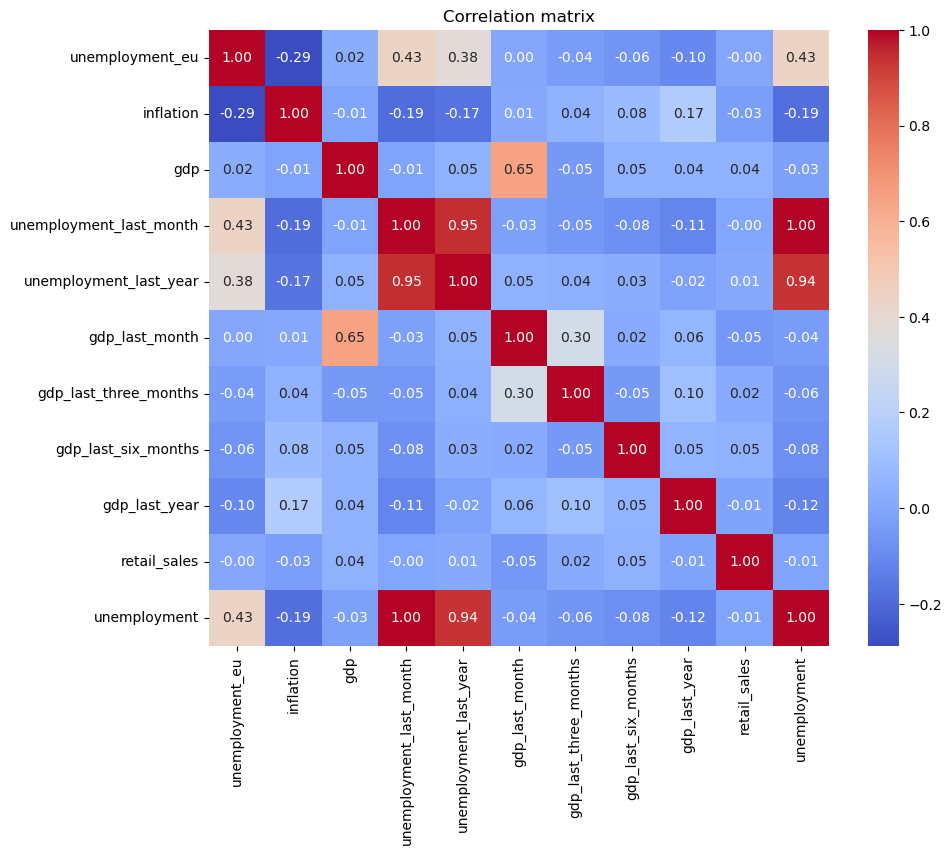

In [1505]:
#Macierz korelacji
corr = df_final.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix")
plt.show()


In [1506]:
#Dropnięcie retail_sales
df_final = df_final.drop(columns=["retail_sales"])

In [1507]:
df_final.head()

,geo,country,time,unemployment_eu,inflation,gdp,unemployment_last_month,unemployment_last_year,gdp_last_month,gdp_last_three_months,gdp_last_six_months,gdp_last_year,unemployment
0,AT,Austria,2001-01-01,9.3,2.3,-0.3,3.7,4.3,0.7,0.7,1.4,0.0,3.6
1,AT,Austria,2001-02-01,9.2,1.8,-0.3,3.6,4.3,-0.3,0.7,1.4,0.0,3.6
2,AT,Austria,2001-03-01,9.2,1.9,-0.3,3.6,4.1,-0.3,0.7,1.4,0.0,3.7
3,AT,Austria,2001-04-01,9.3,2.6,-0.3,3.7,3.8,-0.3,-0.3,0.7,1.1,3.9
4,AT,Austria,2001-05-01,9.3,2.9,-0.3,3.9,3.7,-0.3,-0.3,0.7,1.1,4.0


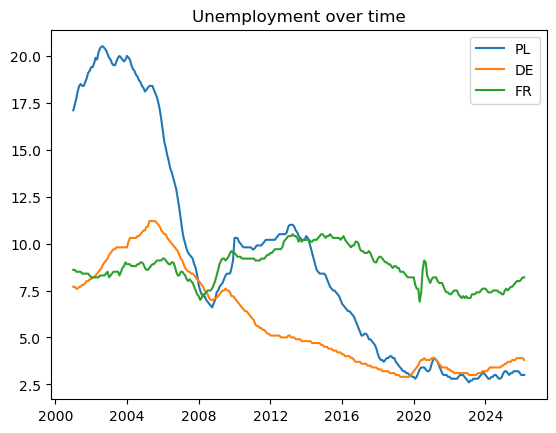

In [1508]:
#Trend bezrobocia dla Polski, Niemiec i Francji
countries = ["PL", "DE", "FR"]

for c in countries:
    subset = df_final[df_final["geo"] == c]
    plt.plot(subset["time"], subset["unemployment"], label=c)

plt.legend()
plt.title("Unemployment over time")
plt.show()

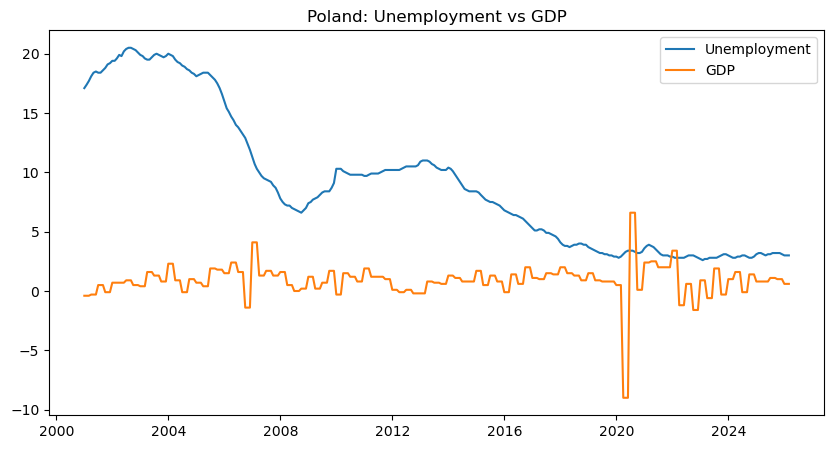

In [1509]:
#Porównanie dla polski bezrobocia i PKB
plt.figure(figsize=(10,5))

subset = df_final[df_final["geo"] == "PL"]

plt.plot(subset["time"], subset["unemployment"], label="Unemployment")
plt.plot(subset["time"], subset["gdp"], label="GDP")

plt.legend()
plt.title("Poland: Unemployment vs GDP")
plt.show()

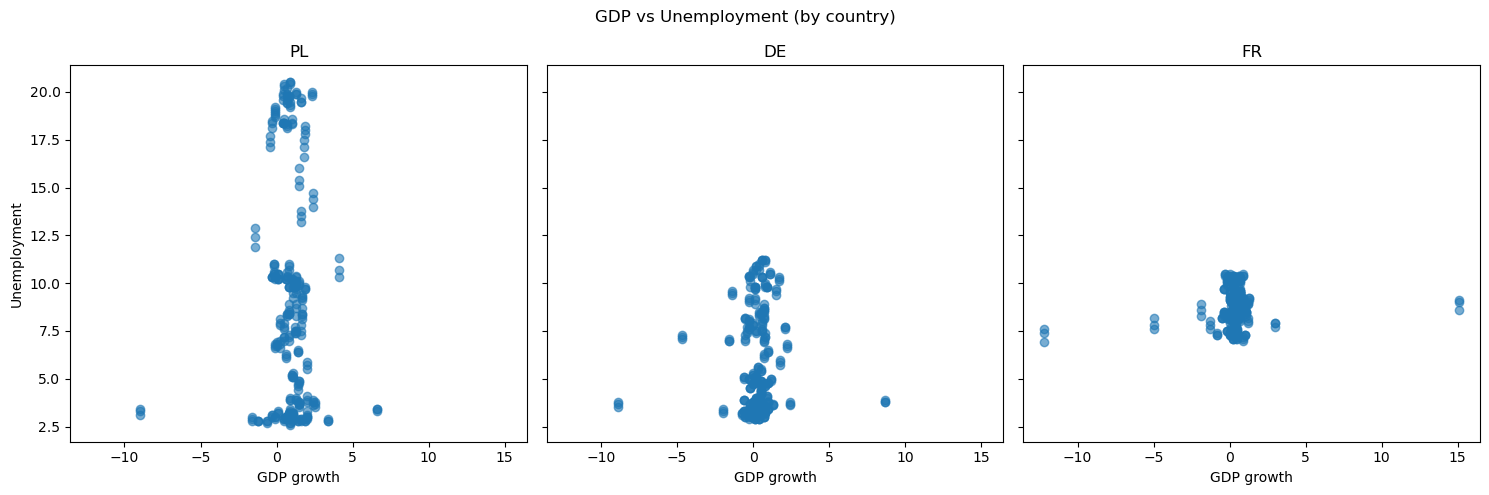

In [1510]:
#PKB vs Bezrobocie
countries = ["PL", "DE", "FR"]

fig, axes = plt.subplots(1, 3, figsize=(15,5), sharex=True, sharey=True)

for i, c in enumerate(countries):
    data = df_final[df_final["geo"] == c]

    axes[i].scatter(
        data["gdp"],
        data["unemployment"],
        alpha=0.6
    )

    axes[i].set_title(c)
    axes[i].set_xlabel("GDP growth")

axes[0].set_ylabel("Unemployment")

plt.suptitle("GDP vs Unemployment (by country)")
plt.tight_layout()
plt.show()


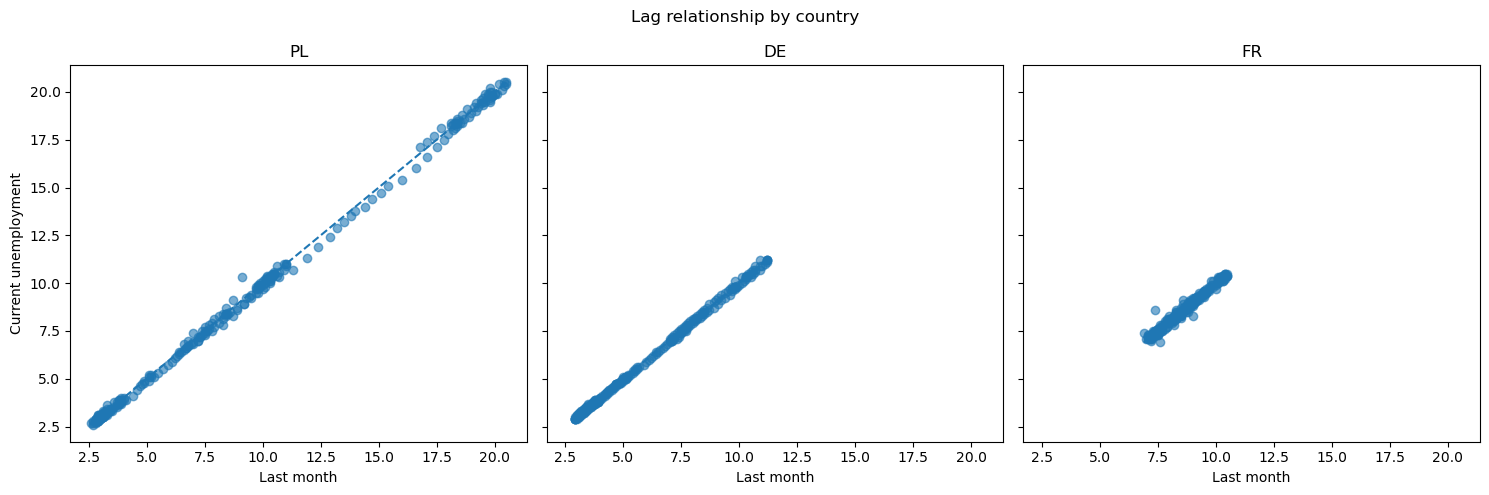

In [1511]:
#Wpływ bezrobocia z poprzedniego miesiąca
countries = ["PL", "DE", "FR"]

fig, axes = plt.subplots(1, 3, figsize=(15,5), sharex=True, sharey=True)

for i, c in enumerate(countries):
    data = df_final[df_final["geo"] == c]

    axes[i].scatter(
        data["unemployment_last_month"],
        data["unemployment"],
        alpha=0.6
    )

    # linia y=x
    min_val = data["unemployment"].min()
    max_val = data["unemployment"].max()
    axes[i].plot([min_val, max_val], [min_val, max_val], linestyle="--")

    axes[i].set_title(c)
    axes[i].set_xlabel("Last month")

# tylko jeden ylabel żeby było clean
axes[0].set_ylabel("Current unemployment")

plt.suptitle("Lag relationship by country")
plt.tight_layout()
plt.show()

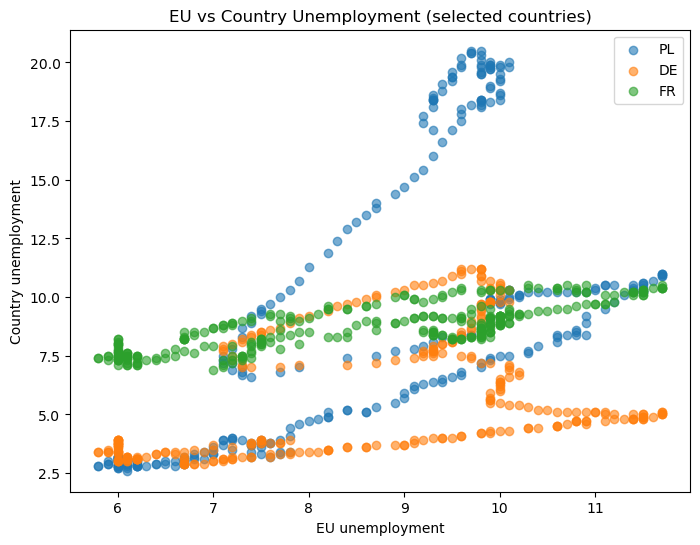

In [1512]:
# countries = ["PL", "DE", "FR"]

subset = df_final[df_final["geo"].isin(countries)]

plt.figure(figsize=(8,6))

for c in countries:
    data = subset[subset["geo"] == c]
    plt.scatter(
        data["unemployment_eu"],
        data["unemployment"],
        label=c,
        alpha=0.6
    )

plt.xlabel("EU unemployment")
plt.ylabel("Country unemployment")
plt.legend()
plt.title("EU vs Country Unemployment (selected countries)")
plt.show()

In [1513]:
#Sortowanie
df_final = df_final.sort_values(["geo", "time"])

#Split po czasie
train = df_final[df_final["time"] < "2020-01-01"]
test  = df_final[df_final["time"] >= "2020-01-01"]

#Podział na treningowe i testowe (wariant 1)
X_train = train[
    [
        "unemployment_last_month",
        "unemployment_last_year",
        "inflation",
        "gdp_last_year",        #Najlepsze gdp
        "unemployment_eu"
    ]
]

y_train = train["unemployment"]

X_test = test[
    [
        "unemployment_last_month",
        "unemployment_last_year",
        "inflation",
        "gdp_last_year",
        "unemployment_eu"
    ]
]

y_test = test["unemployment"]

In [1514]:
#Można by zrobić
#-> Model ze wszystkimi cechami
#-> Model biorący pod uwagę samo bezrobocie w UE
#-> Model biorący pod uwagę inflacje i gdp z zeszlego roku
#I porównać na wykresie